In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("./data/customer_churn_data.csv") # ETL da base de dados são colocados num dataframe

In [ ]:
df.head() # Exemplo da estrutura do nosso dataset

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   int64  
 1   Age              1000 non-null   int64  
 2   Gender           1000 non-null   object 
 3   Tenure           1000 non-null   int64  
 4   MonthlyCharges   1000 non-null   float64
 5   ContractType     1000 non-null   object 
 6   InternetService  703 non-null    object 
 7   TotalCharges     1000 non-null   float64
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
dtypes: float64(2), int64(3), object(5)
memory usage: 78.3+ KB


In [ ]:
df.isna().sum().sum() # Fazendo a limpeza dos dados, partindo dos valores NA, aqui encontramos quase 300 deles

np.int64(297)

In [12]:
df["InternetService"] = df["InternetService"].fillna("")

In [ ]:
df.isna().sum() # Os valores de NA foram limpos

CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

In [ ]:
df.duplicated().sum() # Agora tentamos limpar os dados duplicados, mas a base de dados já não tinha nenhum

np.int64(0)

In [ ]:
df.describe() # Um resumo geral dos dados após a limpeza

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,44.674000,18.97300,74.391290,1404.364060
std,288.819436,9.797741,18.89257,25.712083,1571.755048
min,1.000000,12.000000,0.00000,30.000000,0.000000
25%,250.750000,38.000000,5.00000,52.357500,345.217500
50%,500.500000,45.000000,13.00000,74.060000,872.870000
75%,750.250000,51.000000,26.00000,96.102500,1900.175000
max,1000.000000,83.000000,122.00000,119.960000,12416.250000


In [23]:
numeric_columns_data = df.select_dtypes( include = ["number"]) # Separando dados númericos para trabalhar com eles

In [25]:
# Buscamos correlações entre os valores, a quantidade de valores negativos ou muito baixos demonstra baixa correlação no momento (-1 = strong negative, 1 = strong positive)
numeric_columns_data.corr() 

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
CustomerID,1.000000,0.036730,-0.018585,-0.030504,-0.027490
Age,0.036730,1.000000,0.000472,0.006362,-0.001896
Tenure,-0.018585,0.000472,1.000000,-0.014552,0.894868
MonthlyCharges,-0.030504,0.006362,-0.014552,1.000000,0.304893
TotalCharges,-0.027490,-0.001896,0.894868,0.304893,1.000000


In [5]:
import matplotlib.pyplot as plt

In [26]:
# Vizualizando os dados de churn, notavel que a maioria dos clientes abandona a empresa nesse cenario
df["Churn"].value_counts()

Churn
Yes    883
No     117
Name: count, dtype: int64

In [29]:
# Estudando os dados preliminarmente, analisando a taxa de churn por cobranças mensais, genero, idade, etc.
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
No     62.54641
Yes    75.96077
Name: MonthlyCharges, dtype: float64

In [31]:
df.groupby(["Churn", "Gender"])["MonthlyCharges"].mean()

Churn  Gender
No     Female    65.091912
       Male      59.013878
Yes    Female    74.975064
       Male      77.082518
Name: MonthlyCharges, dtype: float64

In [15]:
df.groupby("Churn")["Tenure"].mean()

Churn
No     30.264957
Yes    17.476784
Name: Tenure, dtype: float64

In [16]:
df.groupby("Churn")["Age"].mean()

Churn
No     43.487179
Yes    44.831257
Name: Age, dtype: float64

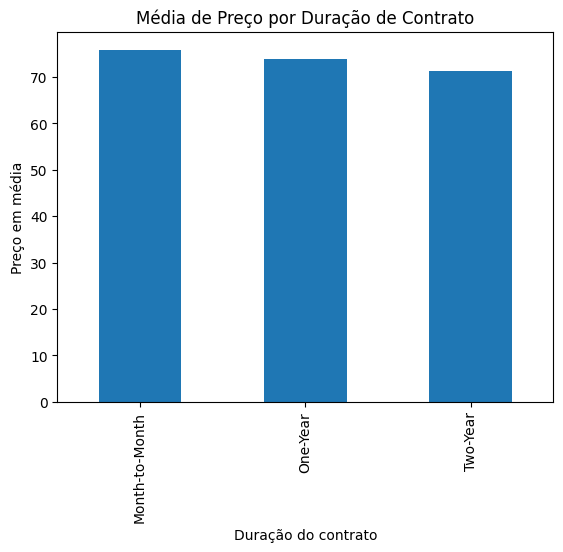

In [ ]:
# Notavel que em geral quanto menor a duração do contrato, maior o custo para o cliente

df.groupby("ContractType")["MonthlyCharges"].mean().plot(kind="bar")
plt.title("Média de Preço por Duração de Contrato")
plt.ylabel("Preço em média")
plt.xlabel("Duração do contrato")
plt.show()

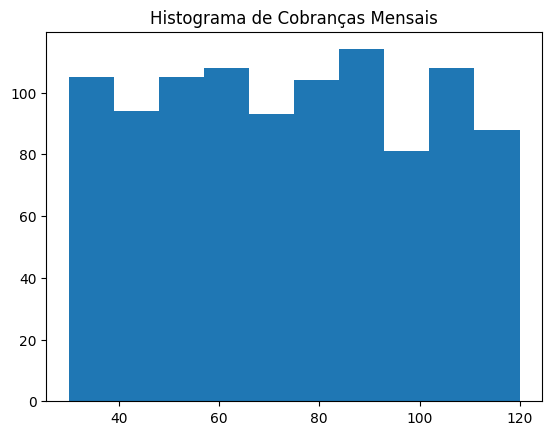

In [ ]:
plt.hist(df["MonthlyCharges"])
plt.title("Histograma de Cobranças Mensais")
plt.show()

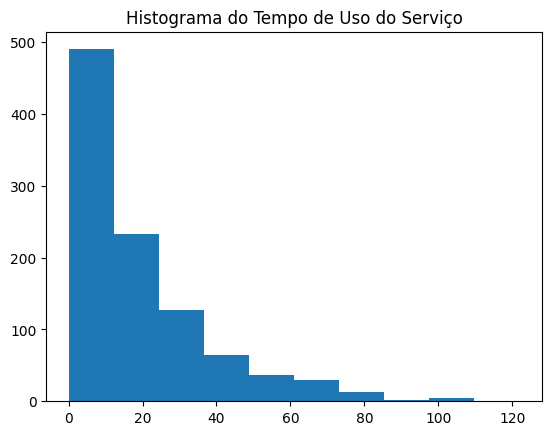

In [ ]:
# A vasta maioria dos clientes usa o serviço por pouco tempo

plt.hist(df["Tenure"])
plt.title("Histograma do Tempo de Uso do Serviço")
plt.show()

In [3]:
# Agora partiremos para feature engineering

y = df[["Churn"]]
X = df[["Age", "Gender", "Tenure", "MonthlyCharges"]]

In [ ]:
X # Para manter todos os dados como numéricos, vamos definir mulheres como 1 e homens como 0

,Age,Gender,Tenure,MonthlyCharges
0,49,Male,4,88.35
1,43,Male,0,36.67
2,51,Female,2,63.79
3,60,Female,8,102.34
4,42,Male,32,69.01
...,...,...,...,...
995,42,Male,41,37.14
996,62,Male,9,80.93
997,51,Female,15,111.72
998,39,Male,68,65.67


In [4]:
X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)

C:\Users\nmarques\AppData\Local\Temp\ipykernel_8156\2388402656.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Gender"] = X["Gender"].apply(lambda x: 1 if x == "Female" else 0)


In [40]:
X.head()

,Age,Gender,Tenure,MonthlyCharges
0,49,0,4,88.35
1,43,0,0,36.67
2,51,1,2,63.79
3,60,1,8,102.34
4,42,0,32,69.01


In [5]:
# Faremos o mesmo com Churn. Sim passa a ser 1 e Não passa a ser 0
y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

C:\Users\nmarques\AppData\Local\Temp\ipykernel_8156\1815220835.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y["Churn"] = y["Churn"].apply(lambda x: 1 if x == "Yes" else 0)


In [46]:
y.head(10)

,Churn
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1
8,0
9,1


In [ ]:
# Preparando o campo pro treinamento do modelo

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
X_train = scaler.fit_transform(X_train)

In [ ]:
# Utilizamos um scaler para manter os dados dentro de ranges parecidos

import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [11]:
X_test= scaler.fit_transform(X_test)